# Introduction to Exploratory Data Analysis (EDA) and Visualization

This notebook is designed to help students learn the fundamental steps for exploratory data analysis (EDA). Each task outlined herein reflects the typical processes a data analyst would perform to understand a dataset, preparing it for further analytical steps.

Through this notebook, students will also gain proficiency in the basics of data visualization using pandas and other libraries. While we won't be building predictive models in this notebook, the practice and insights gained from these EDA exercises will be extremely useful for future modeling endeavors.

# Introduction to Exploratory Data Analysis (EDA) and Visualization

This notebook is designed to help students learn the fundamental steps for exploratory data analysis (EDA). Each task outlined herein reflects the typical processes a data analyst would perform to understand a dataset, preparing it for further analytical steps.

For each task, we provide the 'Intention' of what it is meant to achieve. It will be your practice to figure out how to achieve these intentions. When adopting an AI-assisted coding workflow, it will be your task to determine the right prompt to achieve the desired outcome.

Through this notebook, students will also gain proficiency in the basics of data visualization using pandas and other libraries. While we won't be building predictive models in this notebook, the practice and insights gained from these EDA exercises will be extremely useful for future modeling endeavors.

In [1]:
# import python libaries for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
url = "https://raw.githubusercontent.com/sparks5969/advanced_data_analysis/refs/heads/main/raw_train.csv"
raw_data = pd.read_csv(url)

#Section 1. Exploratory Data Analysis, Getting familiar with your data


## Task 1. Preliminary Exploration

### Task 1.1.1 Dataset information
- intention: get the basic information of this dataset, such as number of raws and columns, non-Null count, datatype,

In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Task 1.1.2. Generate a variable dictionary
- Intention: From the dataset, some of the variable names are self-explanable, while the others are not. We need a variable dictionary to see what's the meaning of each variable

### Task 1.2. Data Type exploration
- Intention: In every dataset, numerical columns and categorical columns need different pre-processing techniques. We first need to know how many numberical columns and how many non-numerical variables exist.

In [4]:
numerical_cols = raw_data.select_dtypes(include=np.number).columns
non_numerical_cols = raw_data.select_dtypes(exclude=np.number).columns

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of non-numerical columns: {len(non_numerical_cols)}")

print("\nNumerical Columns:")
print(list(numerical_cols))

print("\nNon-Numerical Columns:")
print(list(non_numerical_cols))

Number of numerical columns: 38
Number of non-numerical columns: 43

Numerical Columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Non-Numerical Columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'Heating

### Task 1.3. Descriptive Statistics for numerical values
- Intention: let's get to know some descriptive statistics for numerical variables first



In [5]:
raw_data[numerical_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Task 1.4. Explore missing value
- Intention: For columns with missing values, I wanted to know what percentage of the data is missing

In [6]:
missing_data = raw_data.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_percentage = (missing_data / len(raw_data)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})

missing_info = missing_info.sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values and their percentages:")
print(missing_info)

Columns with missing values and their percentages:
              Missing Count  Missing Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageType               81            5.547945
GarageYrBlt              81            5.547945
GarageFinish             81            5.547945
GarageQual               81            5.547945
GarageCond               81            5.547945
BsmtFinType2             38            2.602740
BsmtExposure             38            2.602740
BsmtFinType1             37            2.534247
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
MasVnrArea                8            0.547945
Electrical                1          

## Task 2. Explore the Data with Visuals

### Task 2.1. Visualize "SalePrice"

- Intention: I wanted to get a good understanding on how "SalePrice" is distributed in the dataset.

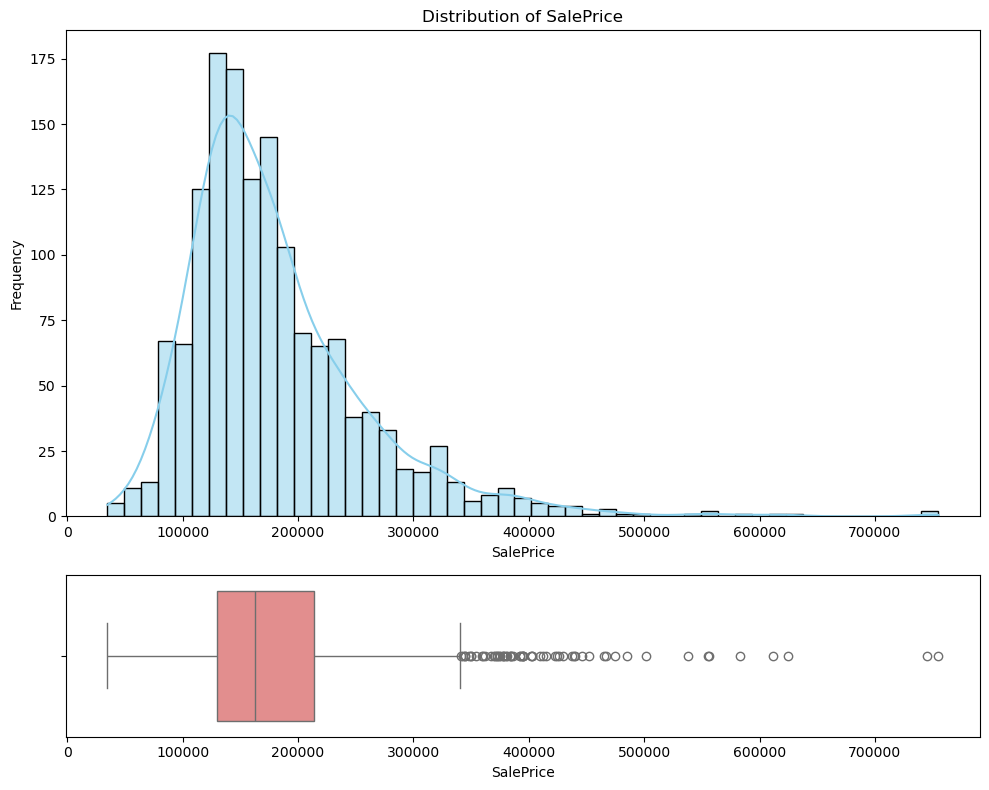

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

sns.histplot(raw_data['SalePrice'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=raw_data['SalePrice'], ax=axes[1], color='lightcoral')
axes[1].set_xlabel('SalePrice')

plt.tight_layout()
plt.show()

## Task 2.2. Visualized the correlation between "Overall Qual" and "SalePrice"
- Intention: Intuitively, "Overall Qual" and "SalePrice" shall be positively correlated. Let's visualize this relationship

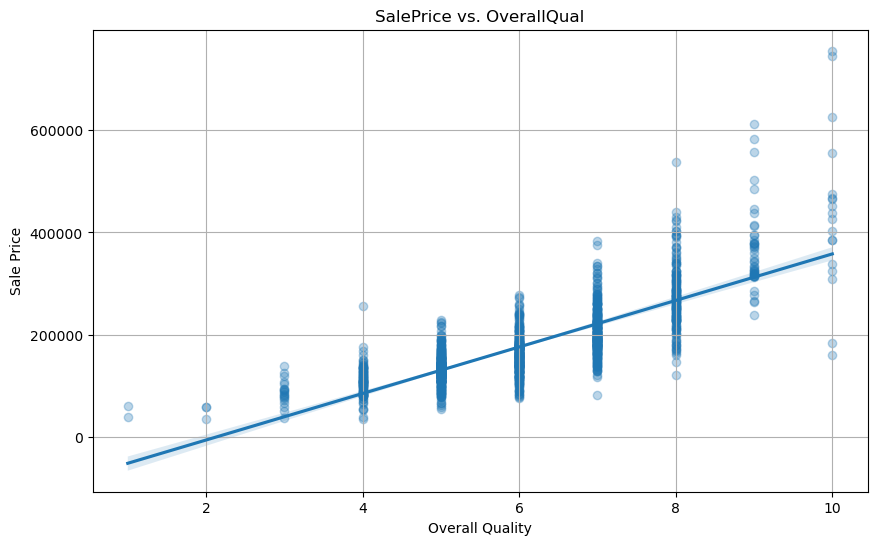

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='OverallQual', y='SalePrice', data=raw_data, scatter_kws={'alpha':0.3})
plt.title('SalePrice vs. OverallQual')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

## Task 2.3. Years Built vs. Price

- Intention: Similar to above, I wanted to explore if Years of Built of a house is correlated with the Sale Price


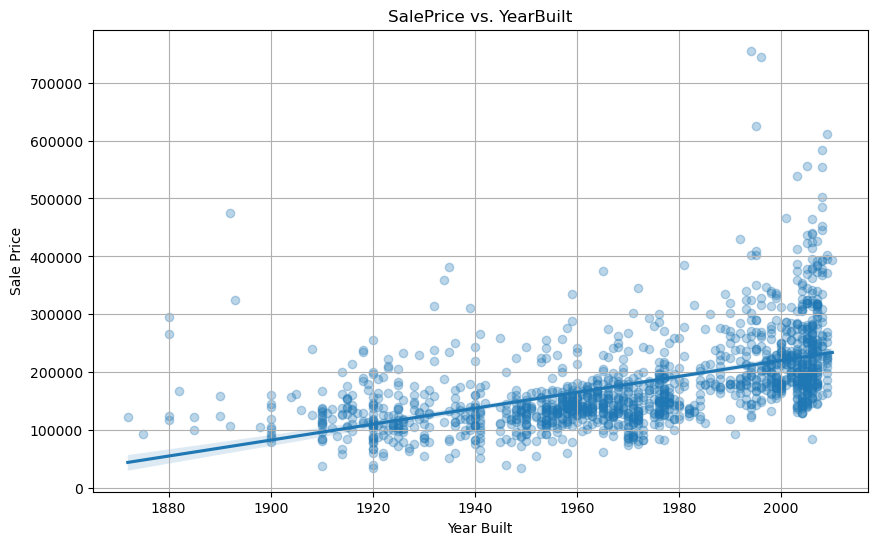

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(x='YearBuilt', y='SalePrice', data=raw_data, scatter_kws={'alpha':0.3})
plt.title('SalePrice vs. YearBuilt')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

## Task 2.4. Overall Quality, Year Built, and Price
- Intention: Let's use visualization to better understand the correlation among the house's overall quality, year built and price.

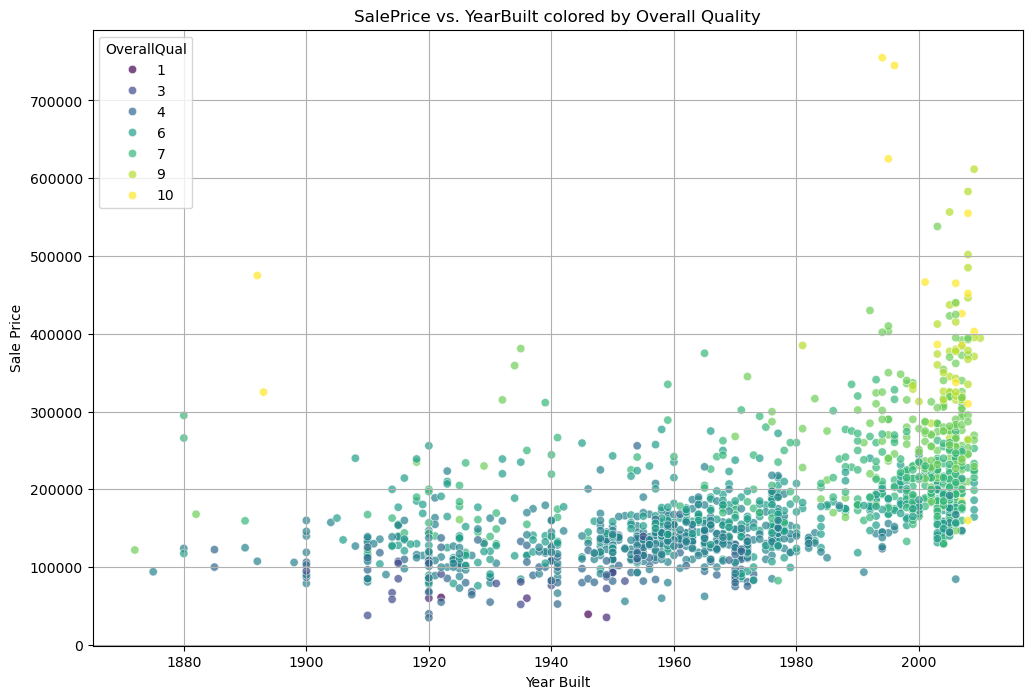

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='YearBuilt', y='SalePrice', hue='OverallQual', data=raw_data, palette='viridis', alpha=0.7)
plt.title('SalePrice vs. YearBuilt colored by Overall Quality')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()


## Task 3. Explore key variables

### Task 3.1. Define the key variables
- Intention: not all variables are equally important. Let's find several variables that might be important and take a deep dive. This step is CRITICALLY IMPROTANT if you need to perform causal-inference type analysis. It is also helpful if you wanted to perform predictive analysis.
- Prompt: Define variable list, name as "selected_variables"\ ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt"]

In [11]:
selected_variables = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt"]

### Task 3.2. Distribution Visualization

- Intention: Use historgram to better understand the distribution of the key variables


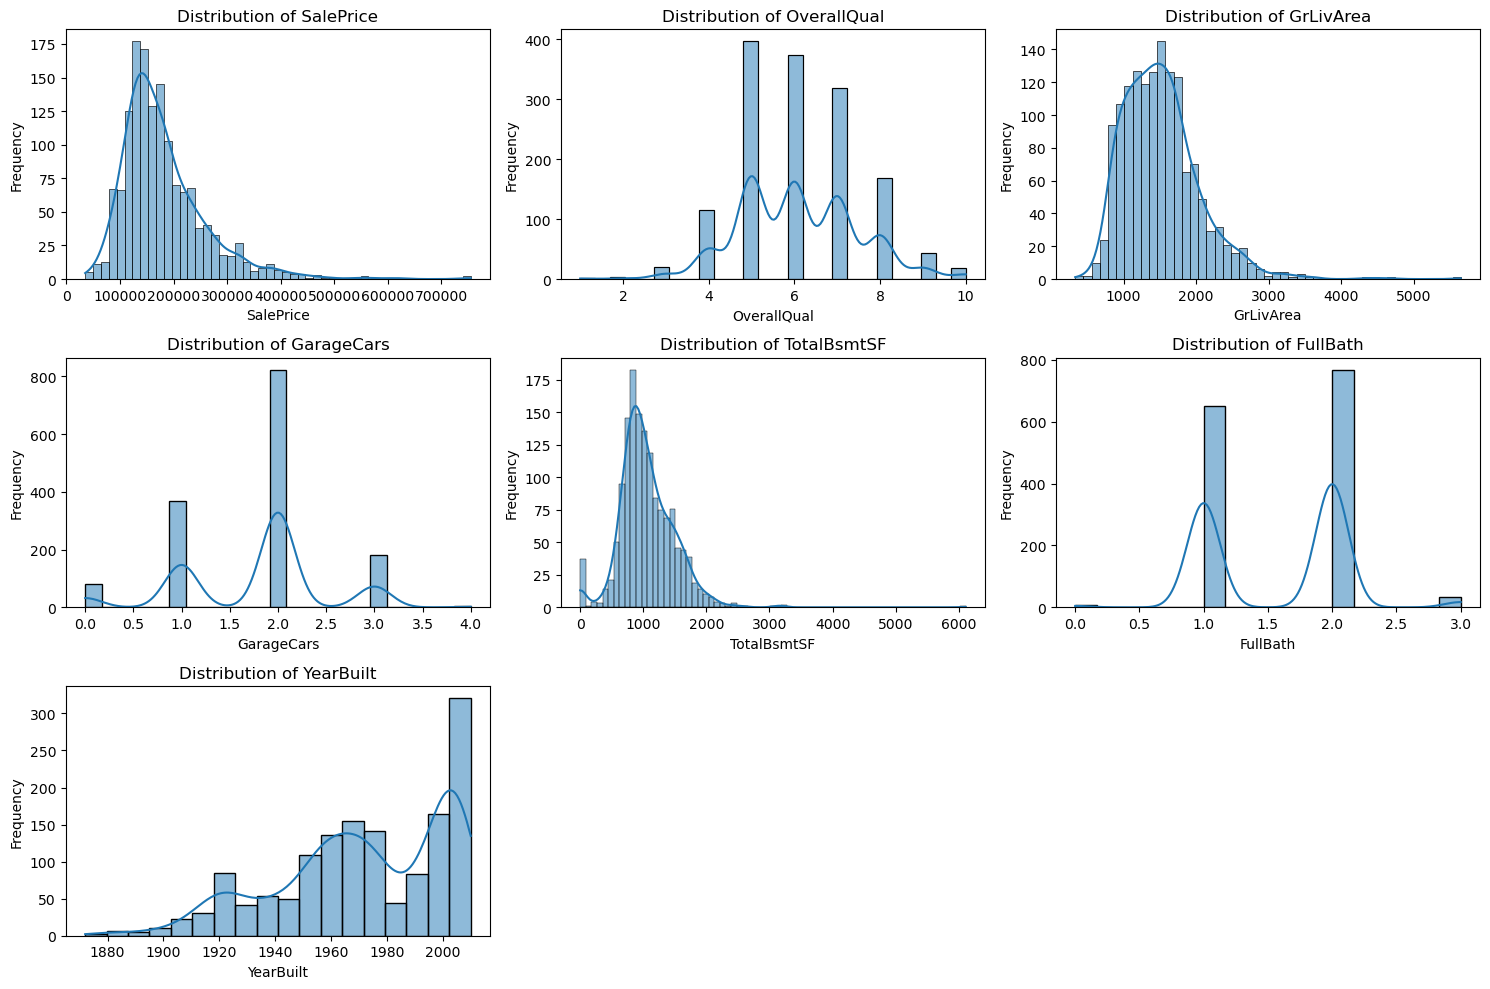

In [12]:
plt.figure(figsize=(15, 10))
for i, var in enumerate(selected_variables):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(raw_data[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Task 3.3. Visualize Pairwise Correlation
- Intention: let's check pairwise correlation among the key variables

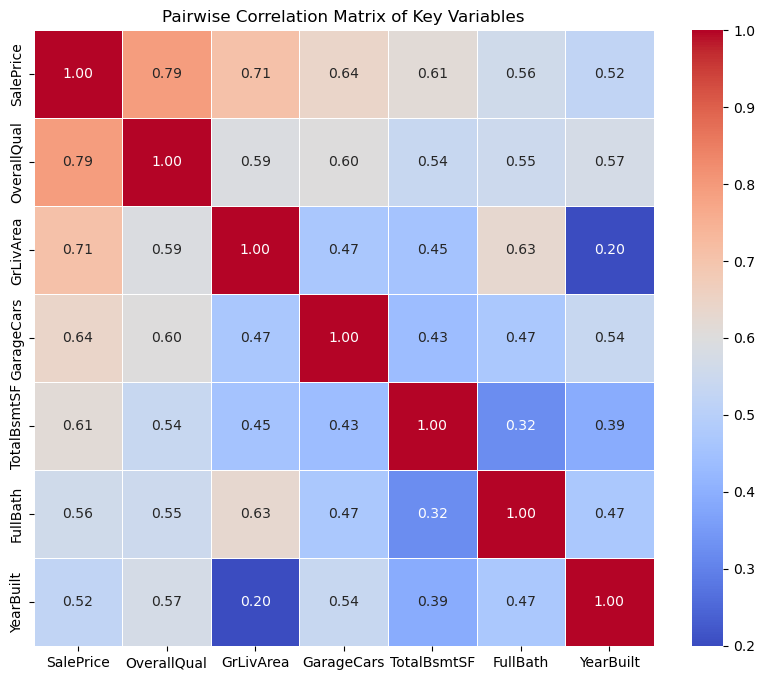

In [13]:
correlation_matrix = raw_data[selected_variables].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pairwise Correlation Matrix of Key Variables')
plt.show()

### Task 3.4. Correlation with "SalePrice"
- Intention: I need to understand how each of those selected variables are correlated with my target variable "SalePrice"

In [14]:
sale_price_correlations = correlation_matrix['SalePrice'].drop('SalePrice')
print(sale_price_correlations.sort_values(ascending=False))

OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
TotalBsmtSF    0.613581
FullBath       0.560664
YearBuilt      0.522897
Name: SalePrice, dtype: float64


### 3.5.1. Correlation Matrix
- Intention: Let's create a matrix to display the correlation among selected variables numerically.
- Prompt: Use "selected_variables" to calculate the full correlation matrix, store the result in "correlation_matrix"

In [15]:
correlation_matrix = raw_data[selected_variables].corr()
print(correlation_matrix)

             SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  \
SalePrice     1.000000     0.790982   0.708624    0.640409     0.613581   
OverallQual   0.790982     1.000000   0.593007    0.600671     0.537808   
GrLivArea     0.708624     0.593007   1.000000    0.467247     0.454868   
GarageCars    0.640409     0.600671   0.467247    1.000000     0.434585   
TotalBsmtSF   0.613581     0.537808   0.454868    0.434585     1.000000   
FullBath      0.560664     0.550600   0.630012    0.469672     0.323722   
YearBuilt     0.522897     0.572323   0.199010    0.537850     0.391452   

             FullBath  YearBuilt  
SalePrice    0.560664   0.522897  
OverallQual  0.550600   0.572323  
GrLivArea    0.630012   0.199010  
GarageCars   0.469672   0.537850  
TotalBsmtSF  0.323722   0.391452  
FullBath     1.000000   0.468271  
YearBuilt    0.468271   1.000000  


### Task 3.5.2. Heatmap for correlation
- Intention: A heatmap could be very useful to see where we have stronger correlations.

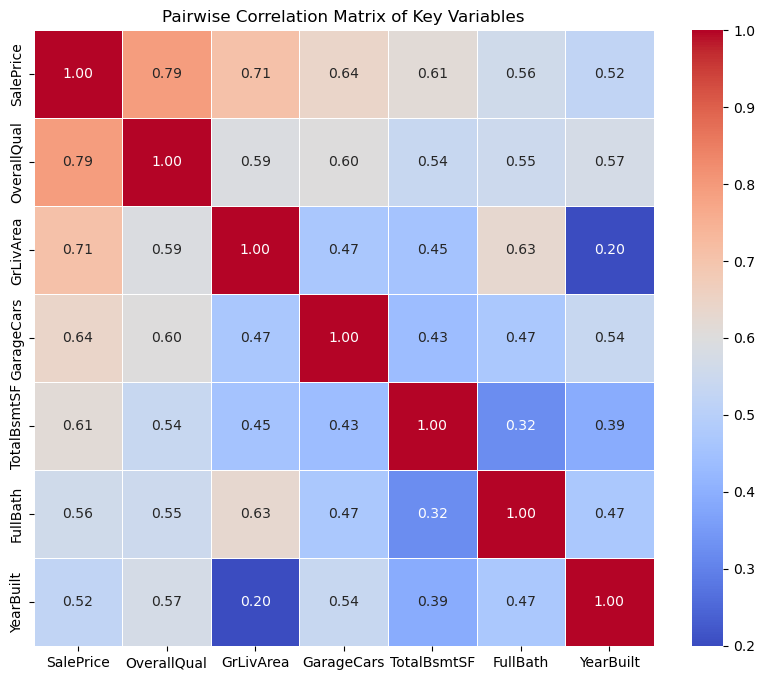

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pairwise Correlation Matrix of Key Variables')
plt.show()

## Task 4. Exploratory Analysis for Categorical Variables

### There are many categorical variables that deserve our attention. Here, we will just take one as an example: "Neighborhood". I encourage you to take the steps here as a template or starting point to explore more categorical variables. The better you understand the dataset, the more confidence you will have in building a model around it.

### Task 4.1. Neiborhood Analysis


### Task 4.1.1. Count neighborhoods and houses
- Intention: Let's figure out how many neighorhoods and houses we have

In [17]:
num_neighborhoods = raw_data['Neighborhood'].nunique()
num_houses = len(raw_data)

print(f"Number of unique neighborhoods: {num_neighborhoods}")
print(f"Total number of houses: {num_houses}")

Number of unique neighborhoods: 25
Total number of houses: 1460


### Task 4.2.2. Median SalePrice by Neighborhood
- Intention: Intuitively, House prices is different in different neighborhoods. Let's check this intuition

In [18]:
neighborhood_prices = raw_data.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
print(neighborhood_prices)

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


### Task 4.2.3.  Visualize top neighborhoods
- Intention: Numbers are boring and hard to read, let's visualize how neibghborhood is associated with Sale Price.


/var/folders/8x/c85f6g11487c2zcq5c2v98j80000gn/T/ipykernel_92071/1468839203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_prices.index, y=neighborhood_prices.values, palette='viridis')


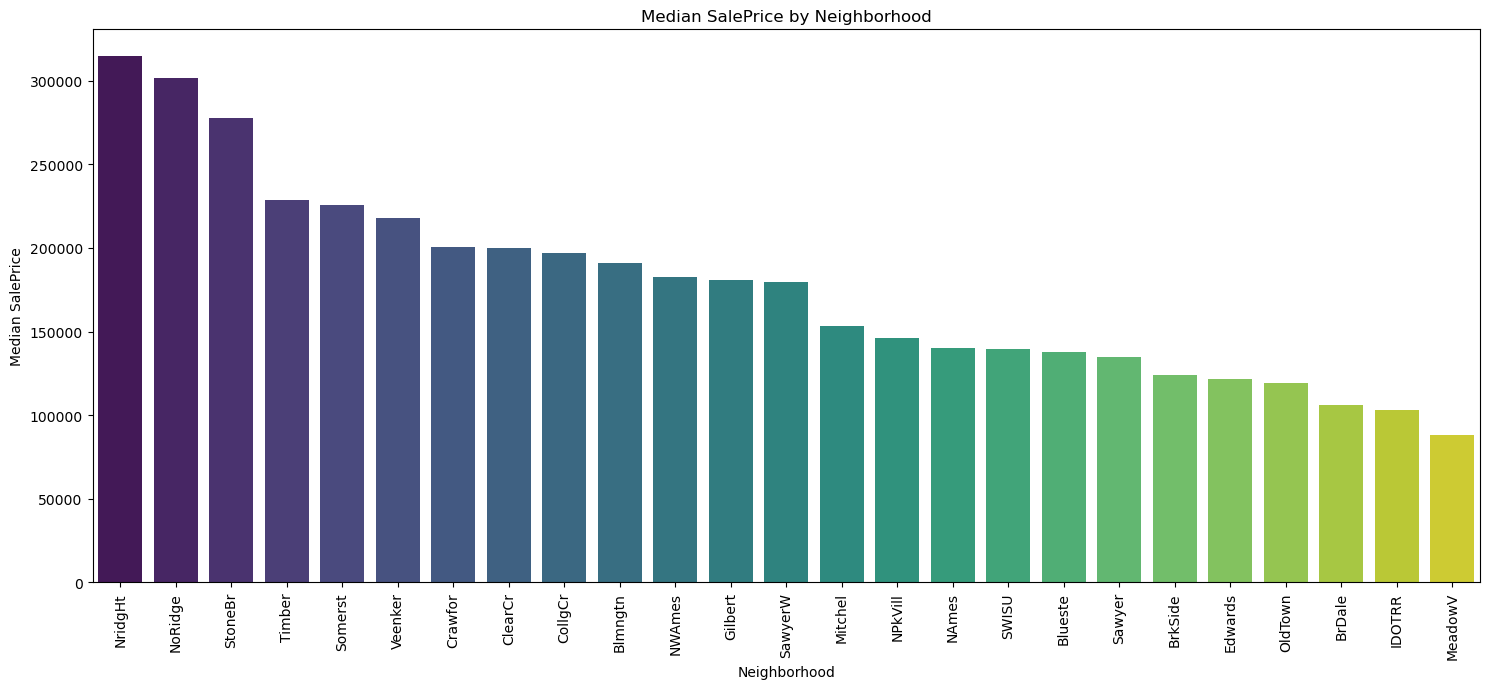

In [19]:
plt.figure(figsize=(15, 7))
sns.barplot(x=neighborhood_prices.index, y=neighborhood_prices.values, palette='viridis')
plt.title('Median SalePrice by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Median SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()